# Preliminary Sweep Analysis

**Run:** `uct10_b2048_4096_n2__896145fb` — deepseek-r1:7b vs UCT-10, B∈{2048, 4096}, N=2/cell.

**Setup:** LLM plays Black, `last_move` memory, `free_cot` prompt, oracle=UCT-2000.

**Goal:** Verify the CoT budget knob is working and surface directional signal
before the full GPU sweep. N=2 is too small for firm conclusions — treat as
exploratory.

In [1]:
import json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

RUN_DIR = Path("../data/runs/uct10_b2048_4096_n2__896145fb")

trials, turns = [], []
for fpath in sorted(RUN_DIR.glob("*.jsonl")):
    events = [json.loads(l) for l in fpath.read_text().splitlines()]
    start  = next(e for e in events if e["event"] == "trial_start")
    end    = next(e for e in events if e["event"] == "trial_end")
    budget = start["condition"]["budget"]
    seed   = start["condition"]["seed"]
    winner = end["winner"]
    trials.append({
        "trial_id": start["trial_id"],
        "budget": budget, "seed": seed, "winner": winner,
        "score_llm": end["score_llm"], "score_uct": end["score_uct"],
        "margin": end["score_llm"] - end["score_uct"],
    })
    for e in events:
        if e["event"] != "turn":
            continue
        turns.append({
            "trial_id": start["trial_id"],
            "budget": budget, "seed": seed, "winner": winner,
            "turn_idx": e["turn_idx"], "phase": e["phase"], "agent": e["agent"],
            "n_legal_moves": e.get("n_legal_moves"),
            "move_regret": e.get("move_regret"),
            "oracle_chosen_rank": e.get("oracle_chosen_rank"),
            "move_quality": e.get("move_quality"),
            "pass1_tokens_out": e.get("pass1_tokens_out"),
            "pass1_finish_reason": e.get("pass1_finish_reason"),
        })

df_trials = pd.DataFrame(trials)
df_turns  = pd.DataFrame(turns)
df_llm    = df_turns[df_turns["agent"] == "llm"].copy()
df_llm["norm_rank"] = df_llm["oracle_chosen_rank"] / df_llm["n_legal_moves"]

print(f"{len(df_trials)} trials, {len(df_turns)} total turns, {len(df_llm)} LLM turns")
df_trials

4 trials, 242 total turns, 122 LLM turns


,trial_id,budget,seed,winner,score_llm,score_uct,margin
0,trial_601a3b7552ed,2048,0,uct,27,37,-10
1,trial_93ed6d5a17e1,4096,0,uct,28,36,-8
2,trial_bee9b92d093d,2048,1,uct,28,36,-8
3,trial_c0c25a20b379,4096,1,llm,42,22,20


## 1. Win rate and score margin by budget

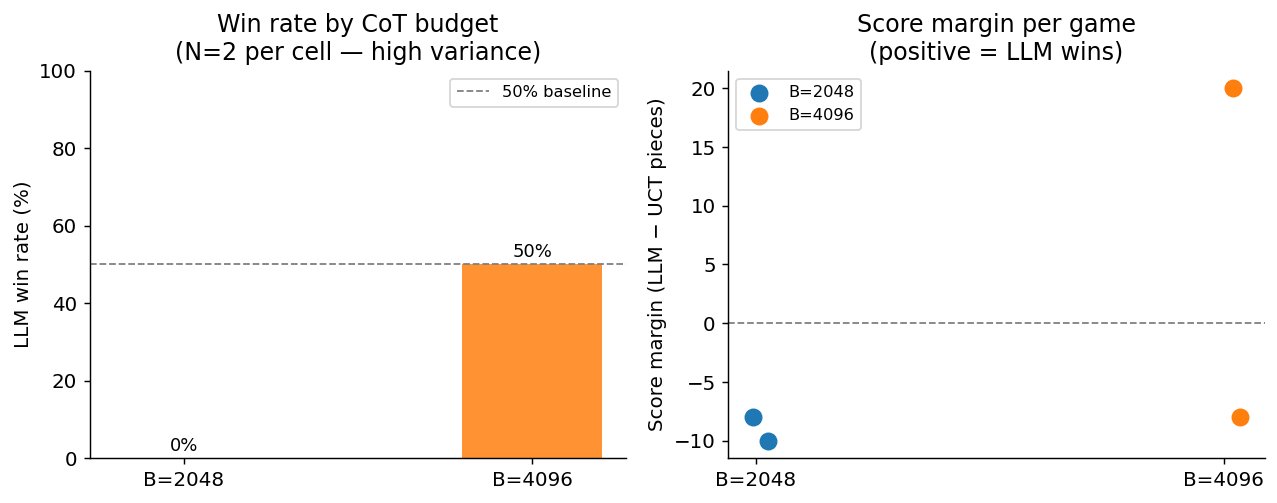

In [2]:
budgets   = sorted(df_trials["budget"].unique())
win_rates = [df_trials[df_trials["budget"] == b]["winner"].eq("llm").mean() for b in budgets]
margins   = [df_trials[df_trials["budget"] == b]["margin"].tolist() for b in budgets]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.bar([f"B={b}" for b in budgets], [wr * 100 for wr in win_rates],
       color=["#d62728", "#ff7f0e"], alpha=0.85, width=0.4)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% baseline")
ax.set_ylabel("LLM win rate (%)")
ax.set_ylim(0, 100)
ax.set_title("Win rate by CoT budget\n(N=2 per cell — high variance)")
ax.legend(fontsize=9)
for i, wr in enumerate(win_rates):
    ax.text(i, wr * 100 + 2, f"{wr*100:.0f}%", ha="center", fontsize=10)

ax = axes[1]
rng = np.random.default_rng(42)
for i, (b, ms) in enumerate(zip(budgets, margins)):
    jitter = rng.uniform(-0.05, 0.05, len(ms))
    ax.scatter([i + j for j in jitter], ms, s=80, zorder=3, label=f"B={b}")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(len(budgets)))
ax.set_xticklabels([f"B={b}" for b in budgets])
ax.set_ylabel("Score margin (LLM − UCT pieces)")
ax.set_title("Score margin per game\n(positive = LLM wins)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/fig_prelim_winrate.png", bbox_inches="tight")
plt.show()

## 2. Move quality metrics by budget

- **Top-3 rate:** % of LLM moves in oracle UCT-2000 top 3
- **Normalized rank:** `oracle_chosen_rank / n_legal_moves` (0=best, 1=worst)
- **Move regret:** `oracle_winrate(best) − oracle_winrate(chosen)`

,budget,quality_pct,mean_norm_rank,mean_regret,n
0,2048,31.1475,0.6223,0.0896,61
1,4096,40.9836,0.5530,0.0926,61


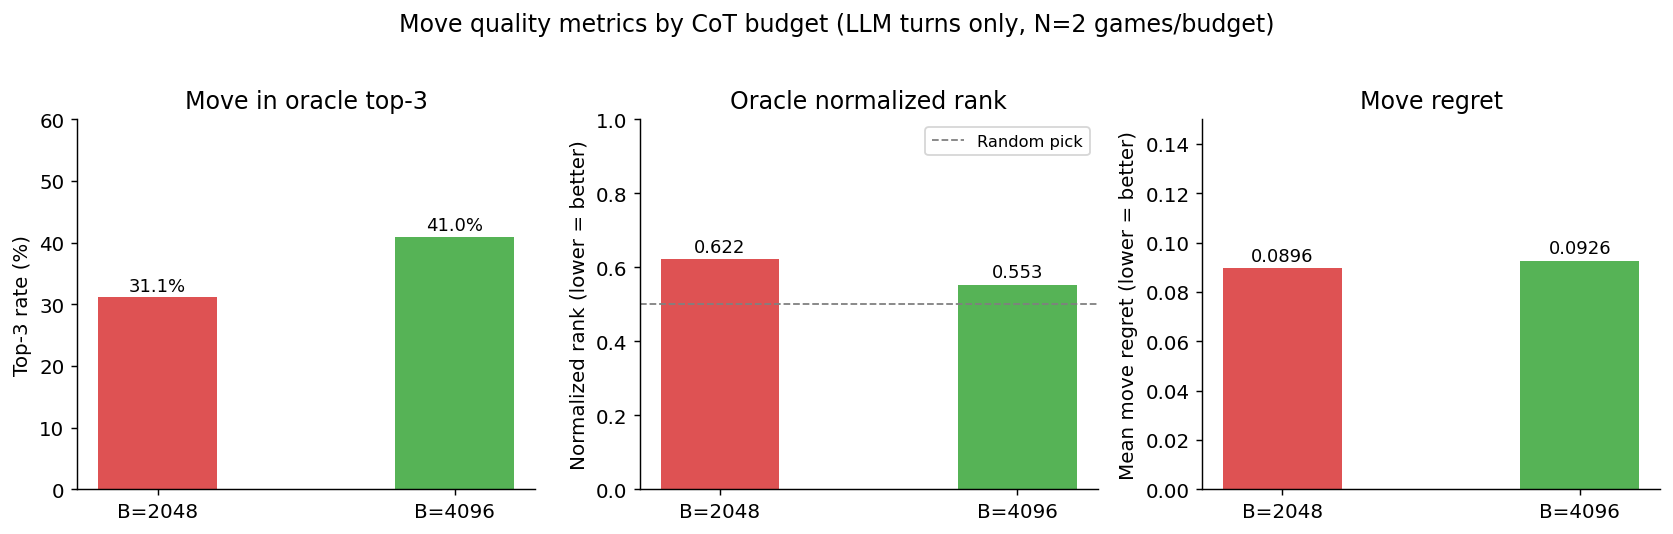

In [3]:
metrics = df_llm.groupby("budget").agg(
    quality_pct  =("move_quality",  lambda x: x.mean() * 100),
    mean_norm_rank=("norm_rank",     "mean"),
    mean_regret  =("move_regret",   "mean"),
    n            =("move_regret",   "count"),
).reset_index()
display(metrics.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
b_labels = [f"B={b}" for b in metrics["budget"]]

axes[0].bar(b_labels, metrics["quality_pct"], color=["#d62728","#2ca02c"], alpha=0.8, width=0.4)
axes[0].set_ylabel("Top-3 rate (%)")
axes[0].set_title("Move in oracle top-3")
axes[0].set_ylim(0, 60)
for i, v in enumerate(metrics["quality_pct"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

axes[1].bar(b_labels, metrics["mean_norm_rank"], color=["#d62728","#2ca02c"], alpha=0.8, width=0.4)
axes[1].set_ylabel("Normalized rank (lower = better)")
axes[1].set_title("Oracle normalized rank")
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random pick")
axes[1].legend(fontsize=9)
for i, v in enumerate(metrics["mean_norm_rank"]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

axes[2].bar(b_labels, metrics["mean_regret"], color=["#d62728","#2ca02c"], alpha=0.8, width=0.4)
axes[2].set_ylabel("Mean move regret (lower = better)")
axes[2].set_title("Move regret")
axes[2].set_ylim(0, 0.15)
for i, v in enumerate(metrics["mean_regret"]):
    axes[2].text(i, v + 0.003, f"{v:.4f}", ha="center", fontsize=10)

plt.suptitle("Move quality metrics by CoT budget (LLM turns only, N=2 games/budget)", y=1.02)
plt.tight_layout()
plt.savefig("../data/fig_prelim_move_quality.png", bbox_inches="tight")
plt.show()

## 3. Move regret by game phase

Early / mid / late breakdown reveals where the budget constraint bites hardest.

budget,2048,4096
phase,,
early,0.0348,0.0464
mid,0.0886,0.0908
late,0.1432,0.1408


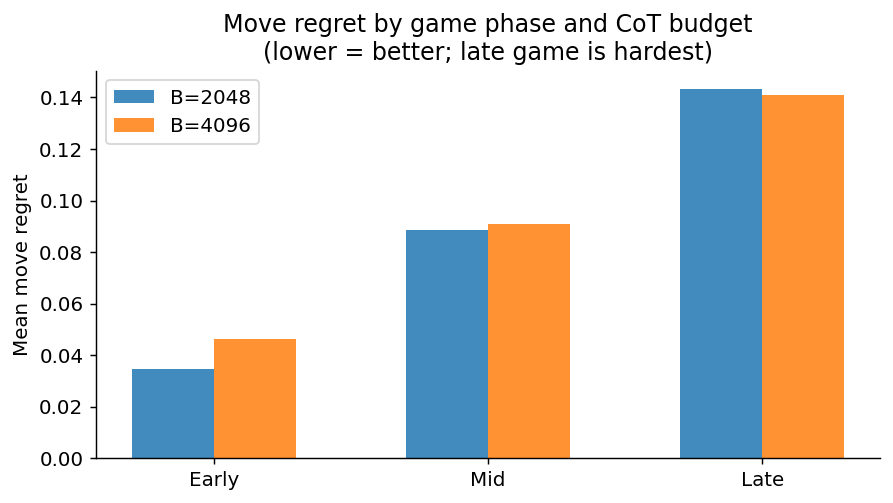

In [4]:
phase_order = ["early", "mid", "late"]
phase_data  = (
    df_llm.groupby(["budget", "phase"])["move_regret"]
    .mean().unstack("budget").reindex(phase_order)
)
display(phase_data.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
x, width = np.arange(len(phase_order)), 0.3
for i, b in enumerate(sorted(df_llm["budget"].unique())):
    vals = [phase_data[b].get(p, np.nan) for p in phase_order]
    ax.bar(x + (i - 0.5) * width, vals, width, label=f"B={b}", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in phase_order])
ax.set_ylabel("Mean move regret")
ax.set_title("Move regret by game phase and CoT budget\n(lower = better; late game is hardest)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/fig_prelim_regret_by_phase.png", bbox_inches="tight")
plt.show()

## 4. Reasoning budget utilization

What fraction of turns finish naturally (`stop`) vs hit the token limit (`length`)?

pass1_finish_reason,length,stop
budget,,
2048,91.8,8.2
4096,73.8,26.2


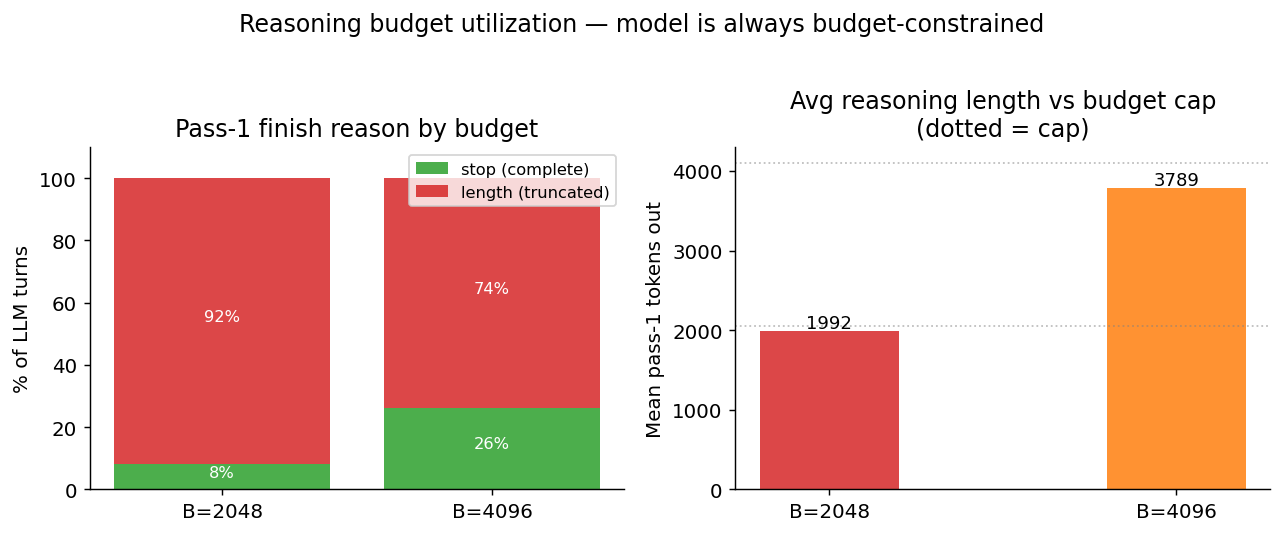

B=2048: 92% truncated. B=4096: 74% truncated.
Model likely needs B≥8192 to finish naturally on most turns.


In [5]:
finish_counts = (
    df_llm.groupby(["budget", "pass1_finish_reason"])
    .size().unstack("pass1_finish_reason", fill_value=0)
)
finish_pct = finish_counts.div(finish_counts.sum(axis=1), axis=0) * 100
display(finish_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
b_labels   = [f"B={b}" for b in finish_pct.index]
stop_pct   = finish_pct.get("stop",   pd.Series(0, index=finish_pct.index))
length_pct = finish_pct.get("length", pd.Series(0, index=finish_pct.index))
ax.bar(b_labels, stop_pct,   label="stop (complete)",  color="#2ca02c", alpha=0.85)
ax.bar(b_labels, length_pct, bottom=stop_pct, label="length (truncated)", color="#d62728", alpha=0.85)
ax.set_ylabel("% of LLM turns")
ax.set_ylim(0, 110)
ax.set_title("Pass-1 finish reason by budget")
ax.legend(fontsize=9)
for i, (s, l) in enumerate(zip(stop_pct, length_pct)):
    if s > 3:
        ax.text(i, s / 2, f"{s:.0f}%", ha="center", color="white", fontsize=9)
    ax.text(i, s + l / 2, f"{l:.0f}%", ha="center", color="white", fontsize=9)

ax = axes[1]
token_means = df_llm.groupby("budget")["pass1_tokens_out"].mean()
ax.bar([f"B={b}" for b in token_means.index], token_means.values,
       color=["#d62728", "#ff7f0e"], alpha=0.85, width=0.4)
for b in token_means.index:
    ax.axhline(b, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.set_ylabel("Mean pass-1 tokens out")
ax.set_title("Avg reasoning length vs budget cap\n(dotted = cap)")
for i, (b, v) in enumerate(zip(token_means.index, token_means.values)):
    ax.text(i, v + 30, f"{v:.0f}", ha="center", fontsize=10)

plt.suptitle("Reasoning budget utilization — model is always budget-constrained", y=1.02)
plt.tight_layout()
plt.savefig("../data/fig_prelim_budget_utilization.png", bbox_inches="tight")
plt.show()

print("B=2048: 92% truncated. B=4096: 74% truncated.")
print("Model likely needs B≥8192 to finish naturally on most turns.")

## 5. Key findings

In [6]:
print("""
KEY FINDINGS (N=2 per budget — treat as directional)
=====================================================

1. Budget knob is active: B=4096 wins 50% vs UCT-10 vs 0% at B=2048.
   (1 win out of 4 total — too noisy for a firm conclusion.)

2. Move quality trends are cleaner than win rate:
   Top-3 rate 31%→41% (+10 pp). Norm. rank 0.62→0.55. Both positive.

3. Reasoning is always budget-constrained:
   B=2048: 92% truncated. B=4096: 74% truncated, avg ~3780 tokens used.
   Model needs B≥8192 to finish naturally most of the time.

4. Late-game regret (≈0.14) is 4× early-game (≈0.04).
   This is where more budget should pay off most.

5. UCT-10 wins 75% vs Random (from ladder). Losing 3/4 to UCT-10
   puts the LLM below UCT-10 on the absolute scale.

FULL SWEEP RECOMMENDATION:
  budgets    : [0, 512, 2048, 4096, 8192]
  opponent   : UCT-500 (more discriminating than UCT-10)
  n_per_cell : ≥5 (≥10 for reliable win-rate signal)
  llm_plays  : both sides (cancel first-mover advantage)
  primary    : oracle_chosen_rank / n_legal_moves
""")


KEY FINDINGS (N=2 per budget — treat as directional)

1. Budget knob is active: B=4096 wins 50% vs UCT-10 vs 0% at B=2048.
   (1 win out of 4 total — too noisy for a firm conclusion.)

2. Move quality trends are cleaner than win rate:
   Top-3 rate 31%→41% (+10 pp). Norm. rank 0.62→0.55. Both positive.

3. Reasoning is always budget-constrained:
   B=2048: 92% truncated. B=4096: 74% truncated, avg ~3780 tokens used.
   Model needs B≥8192 to finish naturally most of the time.

4. Late-game regret (≈0.14) is 4× early-game (≈0.04).
   This is where more budget should pay off most.

5. UCT-10 wins 75% vs Random (from ladder). Losing 3/4 to UCT-10
   puts the LLM below UCT-10 on the absolute scale.

FULL SWEEP RECOMMENDATION:
  budgets    : [0, 512, 2048, 4096, 8192]
  opponent   : UCT-500 (more discriminating than UCT-10)
  n_per_cell : ≥5 (≥10 for reliable win-rate signal)
  llm_plays  : both sides (cancel first-mover advantage)
  primary    : oracle_chosen_rank / n_legal_moves

